In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
data_df = pd.read_csv('data.csv')
data_df = data_df.dropna(subset=['Count'])
data_df

,Date,Name,Count,Point
0,2025-06-01,Аманн,0,БЛУМ
1,2025-06-02,Аманн,0,БЛУМ
2,2025-06-03,Аманн,0,БЛУМ
3,2025-06-04,Аманн,0,БЛУМ
4,2025-06-05,Аманн,0,БЛУМ
...,...,...,...,...
49197,2026-07-04,Фокачча 400х600,8,СПЕЦ_26
49211,2026-07-18,Фокачча 400х600,2,СПЕЦ_26
49473,2026-07-04,Фокачча GN 2/3,2,СПЕЦ_26
51134,2026-07-09,Морнинг бан жасмин,5,СПЕЦ_26


In [5]:
data_df[data_df['Name'] == 'Бабка корица и карамель']

,Date,Name,Count,Point
276,2025-06-01,Бабка корица и карамель,2,БЛУМ
277,2025-06-02,Бабка корица и карамель,1,БЛУМ
278,2025-06-03,Бабка корица и карамель,1,БЛУМ
279,2025-06-04,Бабка корица и карамель,1,БЛУМ
280,2025-06-05,Бабка корица и карамель,1,БЛУМ
...,...,...,...,...
44613,2026-07-20,Бабка корица и карамель,1,СПЕЦ_26
44623,2026-07-30,Бабка корица и карамель,3,СПЕЦ_26
44624,2026-07-31,Бабка корица и карамель,3,СПЕЦ_26
44625,2026-08-01,Бабка корица и карамель,1,СПЕЦ_26


In [6]:
data_df['Date'] = pd.to_datetime(data_df['Date'], errors='coerce')
data_df['Date'].dtype

dtype('<M8[ns]')

In [7]:
data_df['Count'] = pd.to_numeric(data_df['Count'], errors='coerce').fillna(0)

In [8]:
df_2025 = data_df[data_df['Date'].dt.year == 2025].copy()
df_2025

,Date,Name,Count,Point
0,2025-06-01,Аманн,0.0,БЛУМ
1,2025-06-02,Аманн,0.0,БЛУМ
2,2025-06-03,Аманн,0.0,БЛУМ
3,2025-06-04,Аманн,0.0,БЛУМ
4,2025-06-05,Аманн,0.0,БЛУМ
...,...,...,...,...
42742,2025-06-19,Morning bun цедра - кардамон,6.0,СПЕЦ_25
42743,2025-06-20,Morning bun цедра - кардамон,6.0,СПЕЦ_25
42744,2025-06-21,Morning bun цедра - кардамон,6.0,СПЕЦ_25
42745,2025-06-22,Morning bun цедра - кардамон,6.0,СПЕЦ_25


In [8]:
point_sales = df_2025.groupby('Point')['Count'].sum().sort_values(ascending=False)
print("--- 1. КАК ТОВАР РАСПРЕДЕЛЯЕТСЯ МЕЖДУ ТОЧКАМИ? ---")
print(point_sales)
print(f"Всего: {df_2025['Count'].sum()}")
print("\n" + "="*60 + "\n")

--- 1. КАК ТОВАР РАСПРЕДЕЛЯЕТСЯ МЕЖДУ ТОЧКАМИ? ---
Point
ЦЕХ_2025       23118.0
МАЯК            6163.0
ЧАПА_2025       5098.0
БЛУМ            5084.0
Эрна            3197.0
СПЕЦ_25         2230.0
КМ20            1454.0
Тото            1358.0
DODGY           1213.0
Салют            866.0
Pshur            573.0
Bitter Drop      452.0
Чехов и ко       389.0
Полдень          205.0
UCLAD SPACE      112.0
Энтузиаст         55.0
Name: Count, dtype: float64
Всего: 51567.0




In [9]:
print("--- 2. ТОП-3 ТОВАРОВ ДЛЯ КАЖДОЙ ТОРГОВОЙ ТОЧКИ ---")
top_by_point = df_2025.groupby(['Point', 'Name'])['Count'].sum().reset_index()
top_by_point = top_by_point.sort_values(['Point', 'Count'], ascending =[True, False])
print(top_by_point.groupby('Point').head(3).to_string(index=False))

--- 2. ТОП-3 ТОВАРОВ ДЛЯ КАЖДОЙ ТОРГОВОЙ ТОЧКИ ---
      Point                                        Name  Count
Bitter Drop                                 Тартин 0,75  356.0
Bitter Drop                               Тартин гречка   96.0
      DODGY                             Фокачча 400х600 1149.0
      DODGY                                    Доставка   64.0
      Pshur                                 Тартин 0,75  144.0
      Pshur                                Круассан 75г   97.0
      Pshur                             Булка с корицей   95.0
UCLAD SPACE            Синнабоны шоколад-пекан-карамель   42.0
UCLAD SPACE                             Булка с корицей   28.0
UCLAD SPACE                Morning bun цедра - кардамон   21.0
       БЛУМ                 Печенье на закваске шоколад 1260.0
       БЛУМ Бриошь с ванильным кремом в ягодной глазури  928.0
       БЛУМ                              Шу мини жасмин  796.0
       КМ20                          Бриошь для бургера  759.0
    

Деление (Финальный средний балл): Полученную сумму он делит на общее количество строк, которые попали в этот фильтр.
$$ \text{Среднее значение ячейки} = \frac{\text{Сумма всех продаж для дня недели на точке}}{\text{Количество строк для дня недели на точке}} $$


In [ ]:
print(" ---3. Сезонность в какие дни больше продаётся")
df_2025['Day_of_week'] = df_2025['Date'].dt.day_name()
weekly_pattern = df_2025.pivot_table(
    index = 'Day_of_week',
    columns='Point',
    values='Count',
    aggfunc='mean'
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

short_days = {
'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР', 'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday':'ВС'
}
weekly_pattern.index.map(short_days)

print(weekly_pattern)

 ---3. Сезонность в какие дни больше продаётся
Point        Bitter Drop      DODGY     Pshur  UCLAD SPACE      БЛУМ  \
Day_of_week                                                            
Monday          5.000000   9.444444  2.566667     4.090909  0.950226   
Tuesday         5.000000   8.166667  2.464286     4.000000  0.755656   
Wednesday       4.875000   9.500000  2.464286          NaN  0.660633   
Thursday        5.000000   9.833333  2.428571     4.000000  0.703620   
Friday          5.000000   9.944444  2.464286          NaN  0.798643   
Saturday        5.000000   9.388889  3.571429     4.250000  0.789593   
Sunday          5.333333  10.000000  3.457143     4.500000  1.014706   

Point            КМ20      МАЯК   Полдень   СПЕЦ_25     Салют      Тото  \
Day_of_week                                                               
Monday       7.764706  4.413174  3.428571  8.000000  0.273077  4.888889   
Tuesday      8.200000  4.362069  3.500000  6.864865  0.507692  4.606061   
Wedn

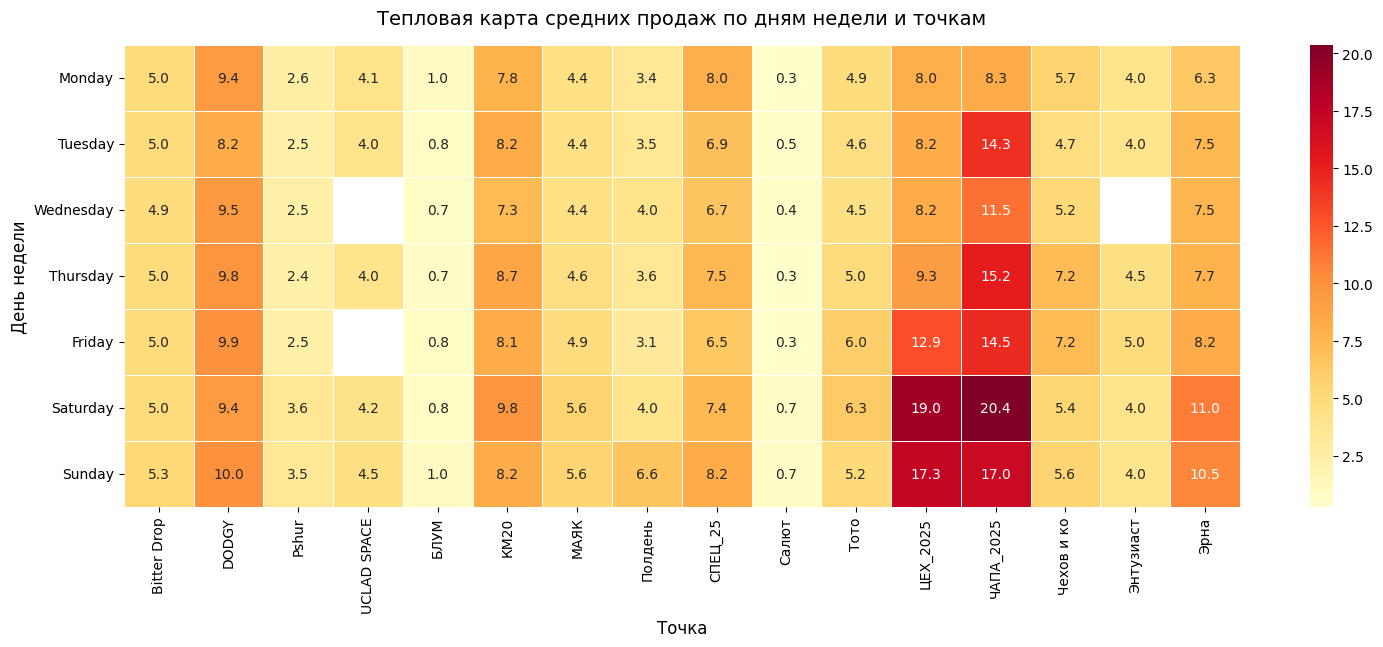

In [16]:
plt.figure(figsize=(18, 6))
sns.heatmap(weekly_pattern, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Тепловая карта средних продаж по дням недели и точкам', fontsize=14, pad=15)
plt.ylabel('День недели', fontsize=12)
plt.xlabel('Точка', fontsize=12)
# plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_12136\4074253994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_total.index, y=weekly_total.values, palette='YlOrRd')


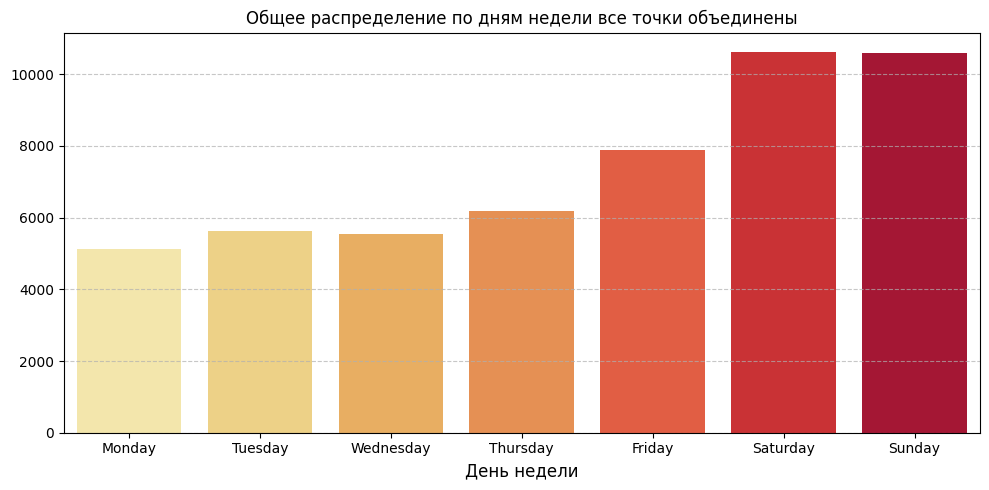

In [17]:
weekly_total = df_2025.groupby('Day_of_week')['Count'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

short_days = {
'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР', 'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday':'ВС'
}
weekly_pattern.index.map(short_days)

plt.figure(figsize=(10, 5))

sns.barplot(x=weekly_total.index, y=weekly_total.values, palette='YlOrRd')
plt.title('Общее распределение по дням недели все точки объединены', fontsize=12)
plt.xlabel('День недели', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Pr

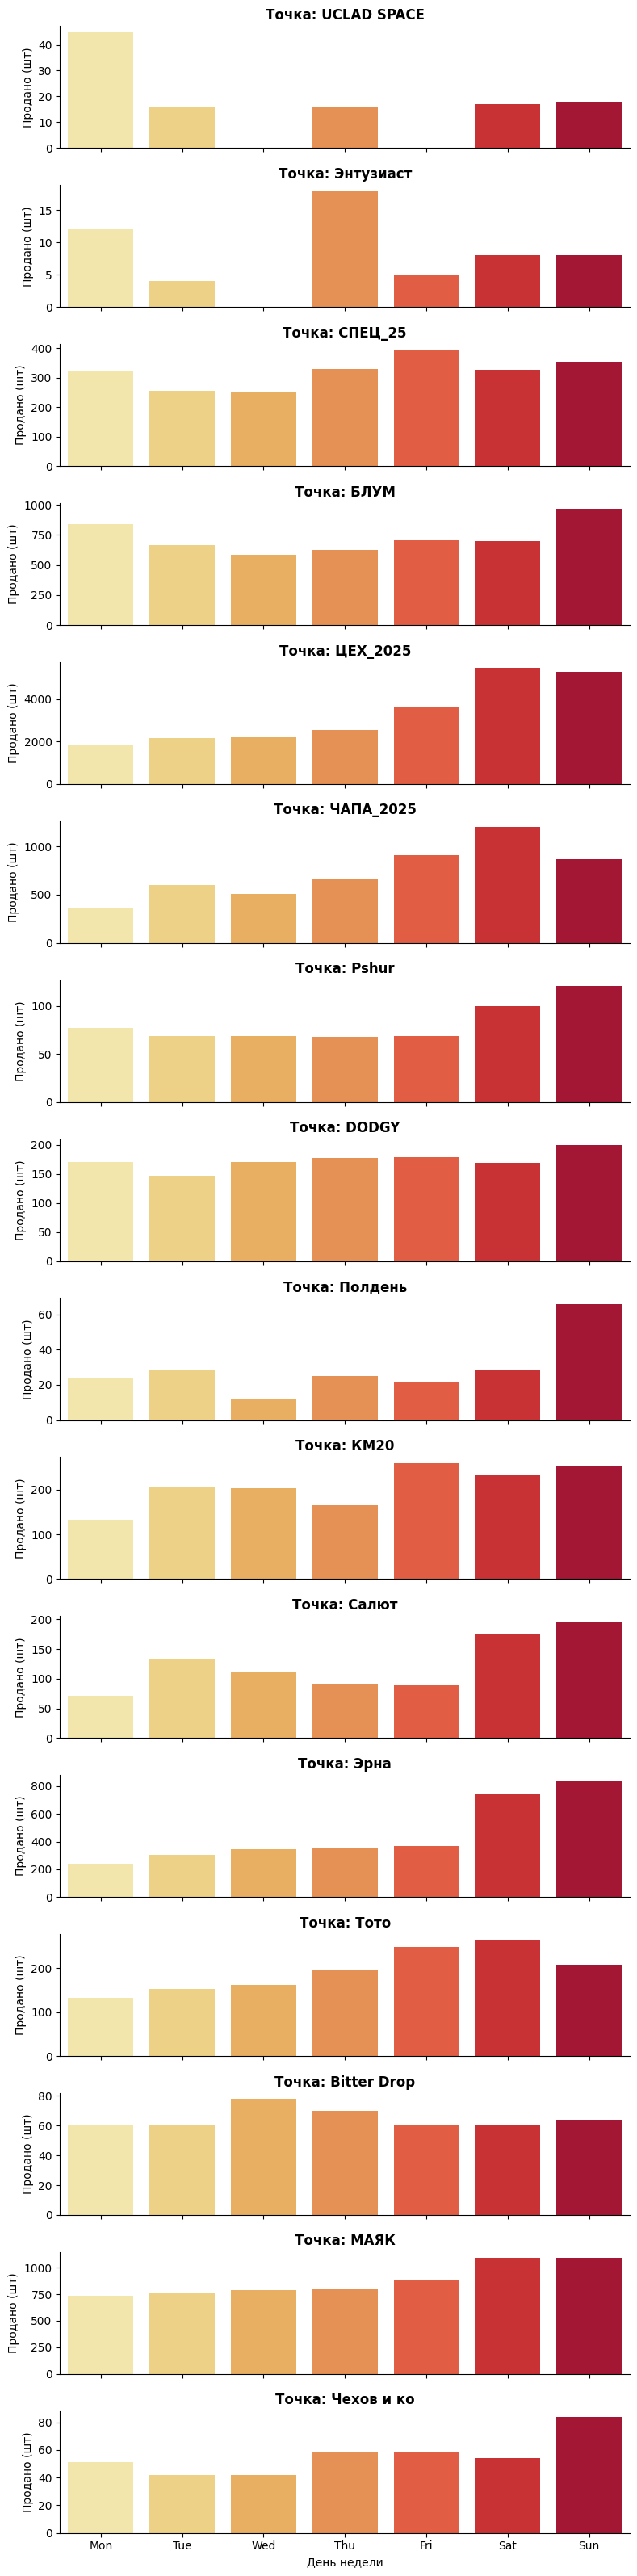

In [18]:
# 1. Считаем сумму продаж для каждого сочетания Точка + День недели
df_grouped = df_2025.groupby(['Point', 'Day_of_week'])['Count'].sum().reset_index()

# 2. Приводим дни недели к короткому виду и сортируем строго от Mon до Sun
short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
df_grouped['Day_of_week'] = df_grouped['Day_of_week'].map(short_days)

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_grouped['Day_of_week'] = pd.Categorical(df_grouped['Day_of_week'], categories=day_order, ordered=True)
df_grouped = df_grouped.sort_values('Day_of_week')

# 3. Настраиваем сетку графиков: col_wrap=1 заставляет графики строиться построчно (в 1 колонку)
# sharey=False важно, чтобы у мелких точек график не превратился в плоскую линию из-за гигантов типа ЦЕХ
g = sns.FacetGrid(df_grouped, row="Point", aspect=4, height=2, sharey=False)

# 4. Заливаем в сетку наши гистограммы (столбчатые диаграммы)
g.map_dataframe(sns.barplot, x="Day_of_week", y="Count", palette="YlOrRd")

# Красиво оформляем оси и заголовки для каждой строки
g.set_titles(row_template="Точка: {row_name}", size=12, weight='bold')
g.set_axis_labels("День недели", "Продано (шт)")

plt.tight_layout()
plt.show()

c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Pr

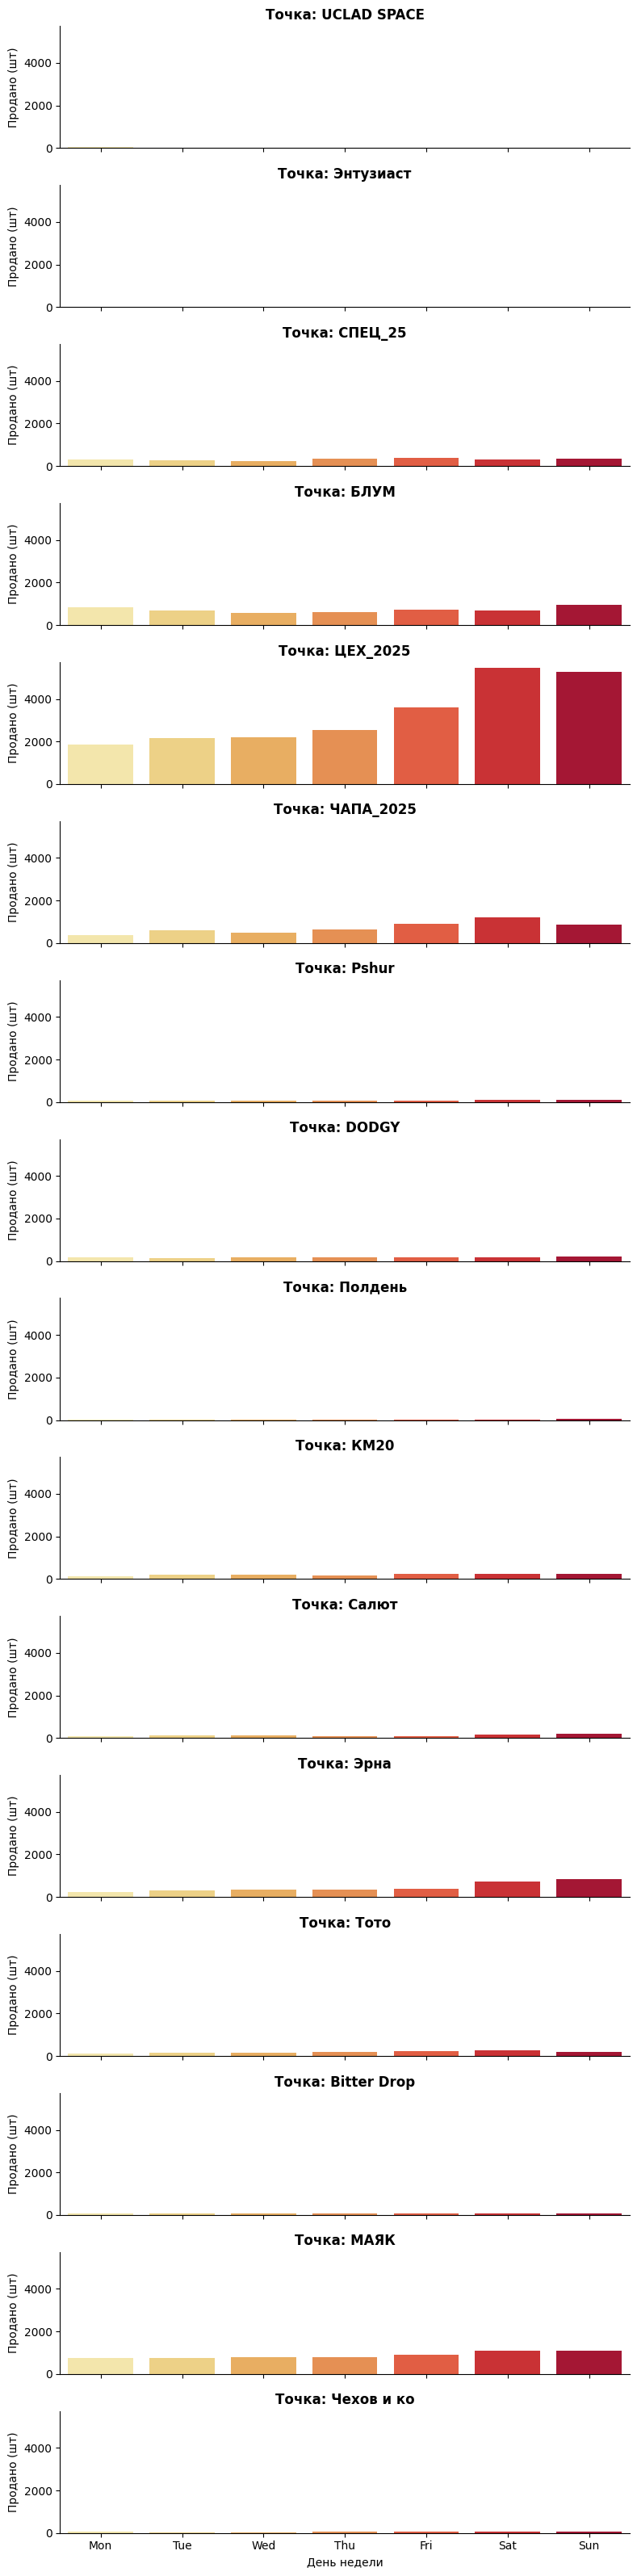

In [20]:

df_grouped = df_2025.groupby(['Point', 'Day_of_week'])['Count'].sum().reset_index()

# 2. Приводим дни недели к короткому виду и сортируем строго от Mon до Sun
short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
df_grouped['Day_of_week'] = df_grouped['Day_of_week'].map(short_days)

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_grouped['Day_of_week'] = pd.Categorical(df_grouped['Day_of_week'], categories=day_order, ordered=True)
df_grouped = df_grouped.sort_values('Day_of_week')

# 3. Настраиваем сетку графиков: col_wrap=1 заставляет графики строиться построчно (в 1 колонку)
# sharey=False важно, чтобы у мелких точек график не превратился в плоскую линию из-за гигантов типа ЦЕХ
g = sns.FacetGrid(df_grouped, row="Point", aspect=4, height=2, sharey=True)

# 4. Заливаем в сетку наши гистограммы (столбчатые диаграммы)
g.map_dataframe(sns.barplot, x="Day_of_week", y="Count", palette="YlOrRd")

# Красиво оформляем оси и заголовки для каждой строки
g.set_titles(row_template="Точка: {row_name}", size=12, weight='bold')
g.set_axis_labels("День недели", "Продано (шт)")

plt.tight_layout()
plt.show()

Мы проверям насколько данные однородны.  
Допустим у нас есть какая то позиция, которая продаётся в один магазин, в большом колличестве (например печенье)
Если такие позиции имеются, без фильтрации данных сложнее интерпретировать графики связанные с общим колличеством всех товаров

In [19]:
product_totals = df_2025.groupby('Name')['Count'].sum().sort_values(ascending=False).to_frame()

total_volume = product_totals['Count'].sum()
product_totals['Share_%'] = (product_totals['Count'] / total_volume) * 100
product_totals['Cumulative_Share_%'] = product_totals['Share_%'].cumsum()
print('TOP 10 по общему объему')
print(product_totals.head(10).to_string())

max_item = product_totals['Count'].max()
median_item = product_totals['Count'].median()
anomaly_ratio = max_item / median_item if median_item > 0 else 0

print(f"Метрика однородности: Самый продаваемый товар превышает МЕДИАННЫЙ товар в {anomaly_ratio:.1f})")

if anomaly_ratio > 50:
    print("КРАЙНЕ НЕОДНОРОДНА")
else:
    print("Структура данных однородна")

TOP 10 по общему объему
                                   Count   Share_%  Cumulative_Share_%
Name                                                                  
Булка с корицей                   4003.0  7.762716            7.762716
Бейгл 100                         3985.0  7.727810           15.490527
Круассан 75г                      3660.0  7.097562           22.588089
Тартин 0,75                       2829.0  5.486067           28.074156
Булка с кардамоном                2583.0  5.009017           33.083173
Булка с маком                     2548.0  4.941145           38.024318
Маритоццо ваниль-мисо карамель    2267.0  4.396222           42.420540
Синнабоны шоколад-пекан-карамель  2253.0  4.369073           46.789614
Печенье на закваске шоколад       1999.0  3.876510           50.666124
Аманн                             1937.0  3.756278           54.422402
Метрика однородности: Самый продаваемый товар превышает МЕДИАННЫЙ товар в 32.8)
Структура данных однородна


In [ ]:

categories_df = pd.read_csv('categories.csv')
categories_df

,Name,Category,Status
0,Аманн,Булки,Активный
1,Аманн Черный кунжут,Булки,Снят
2,Бабка Кардамон,Булки,Снят
3,Бабка Корица,Булки,Снят
4,Бабка корица и карамель,Булки,Активный
...,...,...,...
189,Ромовая баба,Выпечка,Активный
190,Кекс шоколад (целый),Десерты,Активный
191,Кекс мак-лимон (целый),Десерты,Активный
192,Бриошь на бургер 80г,Продукт,Активный


In [10]:
df_2025 = pd.merge(df_2025, categories_df, on="Name", how="left")
df_2025

,Date,Name,Count,Point,Category,Status
0,2025-06-01,Аманн,0.0,БЛУМ,Булки,Активный
1,2025-06-02,Аманн,0.0,БЛУМ,Булки,Активный
2,2025-06-03,Аманн,0.0,БЛУМ,Булки,Активный
3,2025-06-04,Аманн,0.0,БЛУМ,Булки,Активный
4,2025-06-05,Аманн,0.0,БЛУМ,Булки,Активный
...,...,...,...,...,...,...
13307,2025-06-19,Morning bun цедра - кардамон,6.0,СПЕЦ_25,Булки,Снят
13308,2025-06-20,Morning bun цедра - кардамон,6.0,СПЕЦ_25,Булки,Снят
13309,2025-06-21,Morning bun цедра - кардамон,6.0,СПЕЦ_25,Булки,Снят
13310,2025-06-22,Morning bun цедра - кардамон,6.0,СПЕЦ_25,Булки,Снят


In [13]:
missing_categories = df_2025[df_2025['Category'].isna()]['Name'].unique()

for missing in missing_categories:
    print(f"category {missing} | count {df_2025[df_2025['Name'] == missing]['Count'].sum()}")
if len(missing_categories) > 0:
    print("⚠️ Внимание! Следующие товары из продаж не нашлись в справочнике категорий:")
    print(missing_categories)
    print("\nИсправьте их в csv-файле или в коде, иначе они выпадут из общего анализа по категориям!")
else:
    print("✅ Идеально! Все товары успешно получили свои категории, пропусков нет.")

category Бабка карамелизированный шоколад и кокос | count 0.0
category Бейгл 120 | count 20.0
category Бриошь с ванильным кремом в ягодной глазури | count 928.0
category Ватрушка брусника-ваниль | count 0.0
category Даниш Баннофи | count 0.0
category Кекс лимон-малина | count 52.0
category Краснопролетарская (студио) | count 0.0
category Круассан с кремом и компоте | count 0.0
category Мини даниш с курдом | count 0.0
category Шу мини жасмин | count 796.0
category Шу мини малина-ваниль | count 0.0
category Шу мини earl grey | count 0.0
category Гранола грецкий орех-клюква | count 347.0
category Амман с цедрой лайма | count 0.0
category Доставка | count 64.0
category Honey butter toast | count 522.0
⚠️ Внимание! Следующие товары из продаж не нашлись в справочнике категорий:
['Бабка карамелизированный шоколад и кокос' 'Бейгл 120'
 'Бриошь с ванильным кремом в ягодной глазури' 'Ватрушка брусника-ваниль'
 'Даниш Баннофи' 'Кекс лимон-малина' 'Краснопролетарская (студио)'
 'Круассан с кремом 

In [ ]:
df_2025[df_2025['Name'] == '']